# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


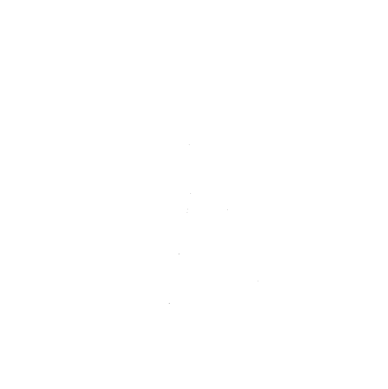

Threshold value: 50


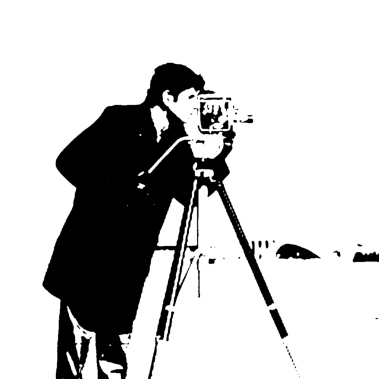

Threshold value: 100


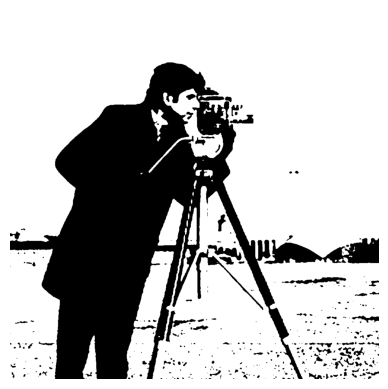

Threshold value: 150


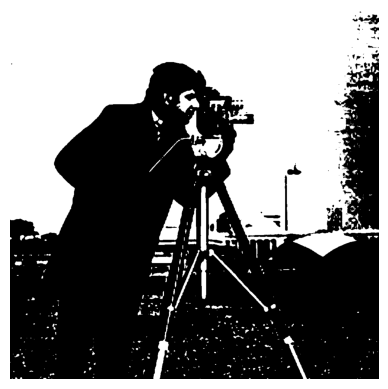

Threshold value: 200


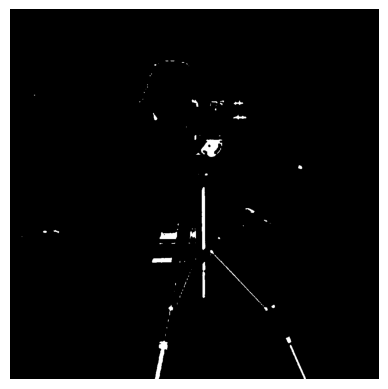

In [11]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    plt.imshow(thresh_img, cmap='gray')
    plt.axis('off')
    plt.show()

Original Image: 


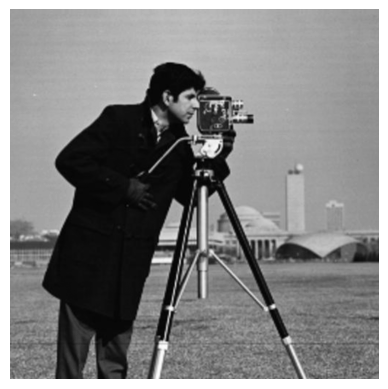

In [12]:
print("Original Image: ")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## Histograms

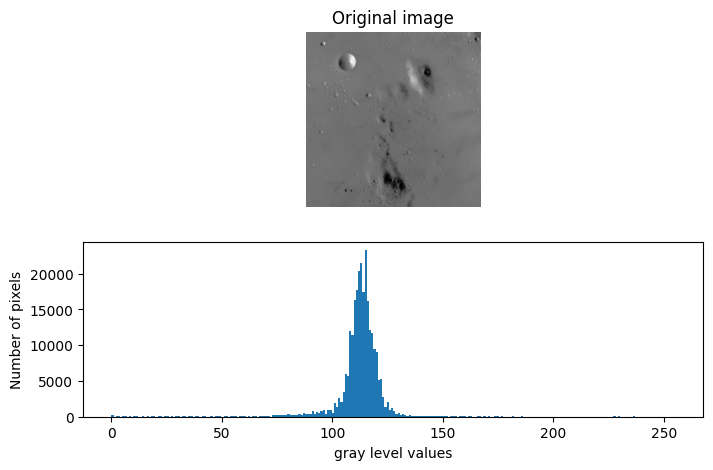

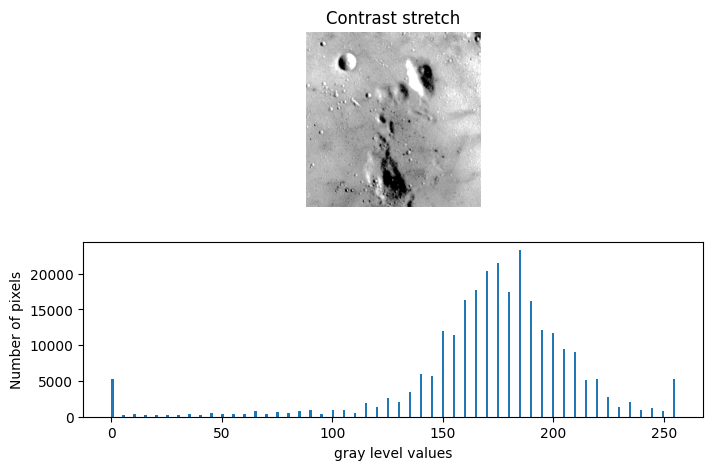

In [13]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


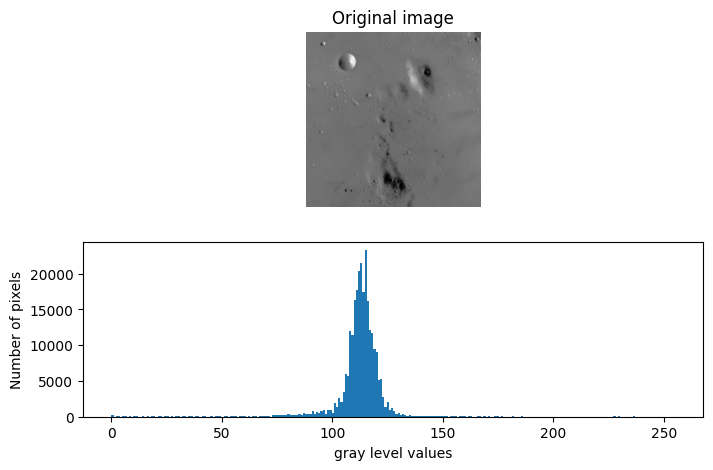

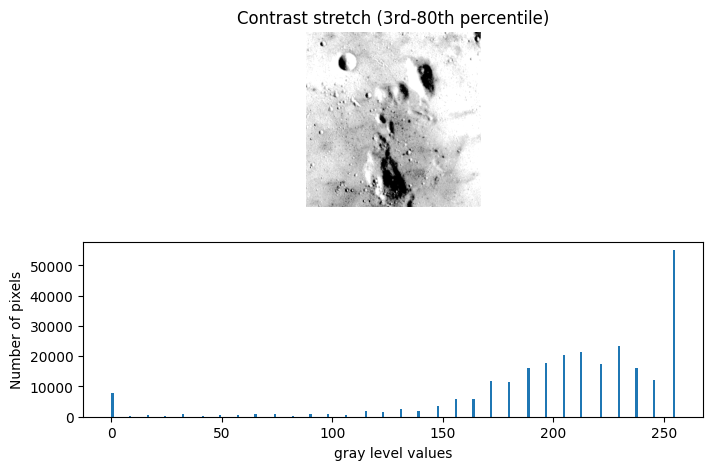

In [14]:
# Task 1: Rescale intensity values to include the 3rd to 80th percentile range
p3, p80 = np.percentile(img, (3, 80))
img_rescale_t1 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_t1, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd-80th percentile)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_t1.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

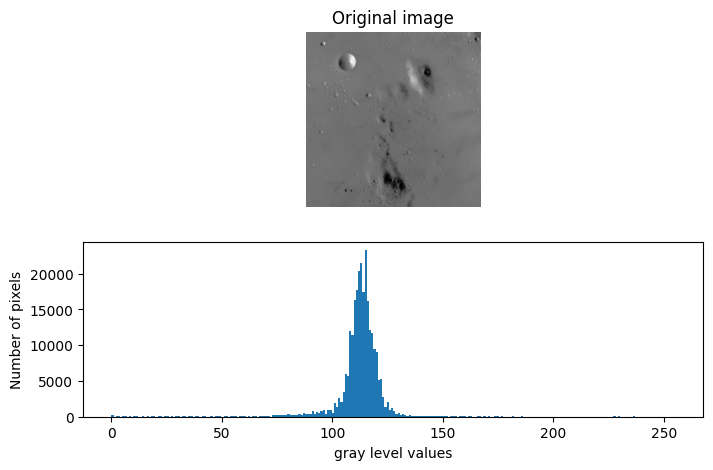

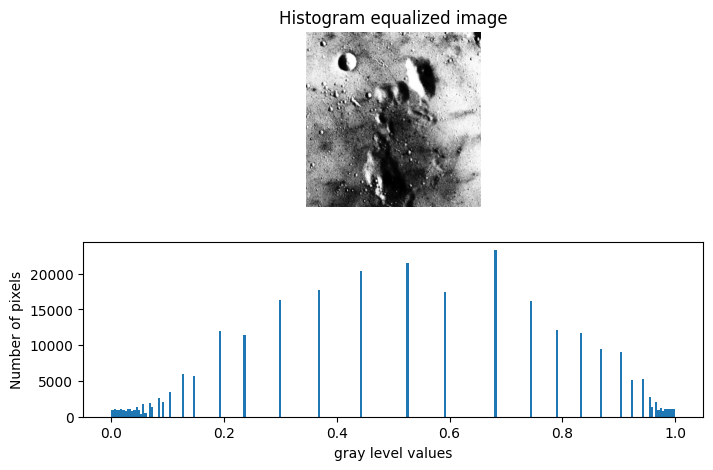

In [15]:
# Task 2: Histogram equalization using exposure.equalize_hist
img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram equalized image')

fig.add_subplot(2, 1, 2)
# equalize_hist returns float values in [0, 1]
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

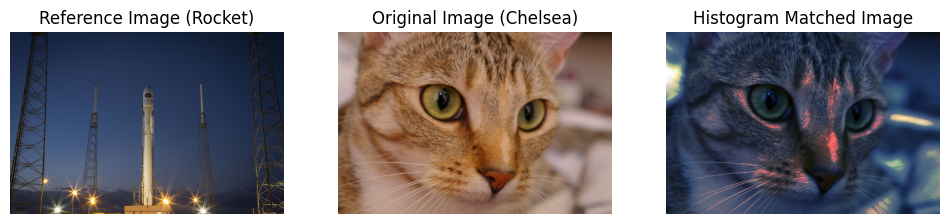

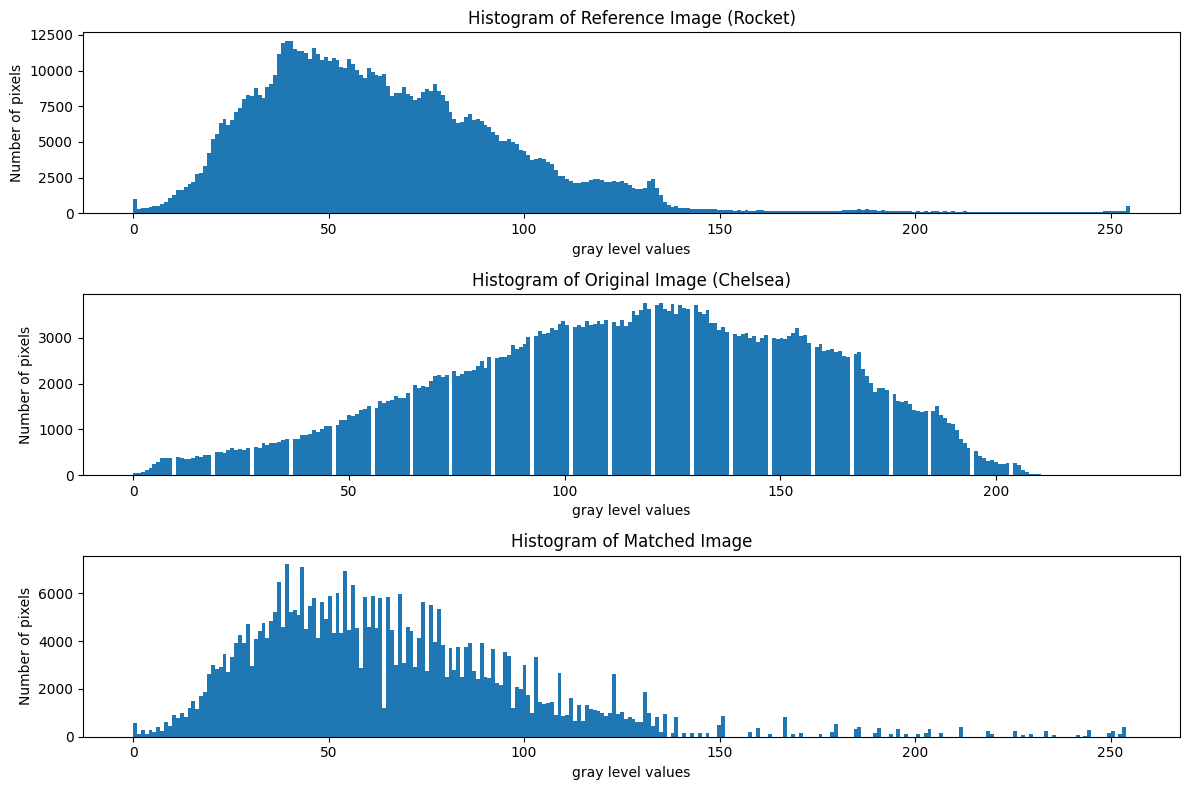

In [17]:
# Task#3: Histogram Equalization

reference = data.rocket()
image = data.chelsea()

# Step#2: Match the histogram of the chelsea image
# to the histogram of the rocket image
matched = exposure.match_histograms(image, reference, channel_axis=-1)

# Step#3: Display the reference, original and matched images
fig = plt.figure(figsize=(12, 8))

fig.add_subplot(1, 3, 1)
plt.imshow(reference)
plt.axis('off')
plt.title('Reference Image (Rocket)')

fig.add_subplot(1, 3, 2)
plt.imshow(image)
plt.axis('off')
plt.title('Original Image (Chelsea)')

fig.add_subplot(1, 3, 3)
plt.imshow(matched)
plt.axis('off')
plt.title('Histogram Matched Image')

plt.show()

# Step#4: Display the histograms
fig = plt.figure(figsize=(12, 8))

fig.add_subplot(3, 1, 1)
plt.hist(reference.ravel(), bins=256)
plt.title('Histogram of Reference Image (Rocket)')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

fig.add_subplot(3, 1, 2)
plt.hist(image.ravel(), bins=256)
plt.title('Histogram of Original Image (Chelsea)')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

fig.add_subplot(3, 1, 3)
plt.hist(matched.ravel(), bins=256)
plt.title('Histogram of Matched Image')
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

plt.tight_layout()
plt.show()